# Transformer

论文地址："Attention is All You Need": https://arxiv.org/abs/1706.03762

## 0, 参考资料
- Word Embedding: https://medium.com/deeper-learning/glossary-of-deep-learning-word-embedding-f90c3cec34ca


学习资料
- illustrated-transformer, https://jalammar.github.io/illustrated-transformer/
- 注意力机制综述（图解完整版附代码） https://zhuanlan.zhihu.com/p/631398525

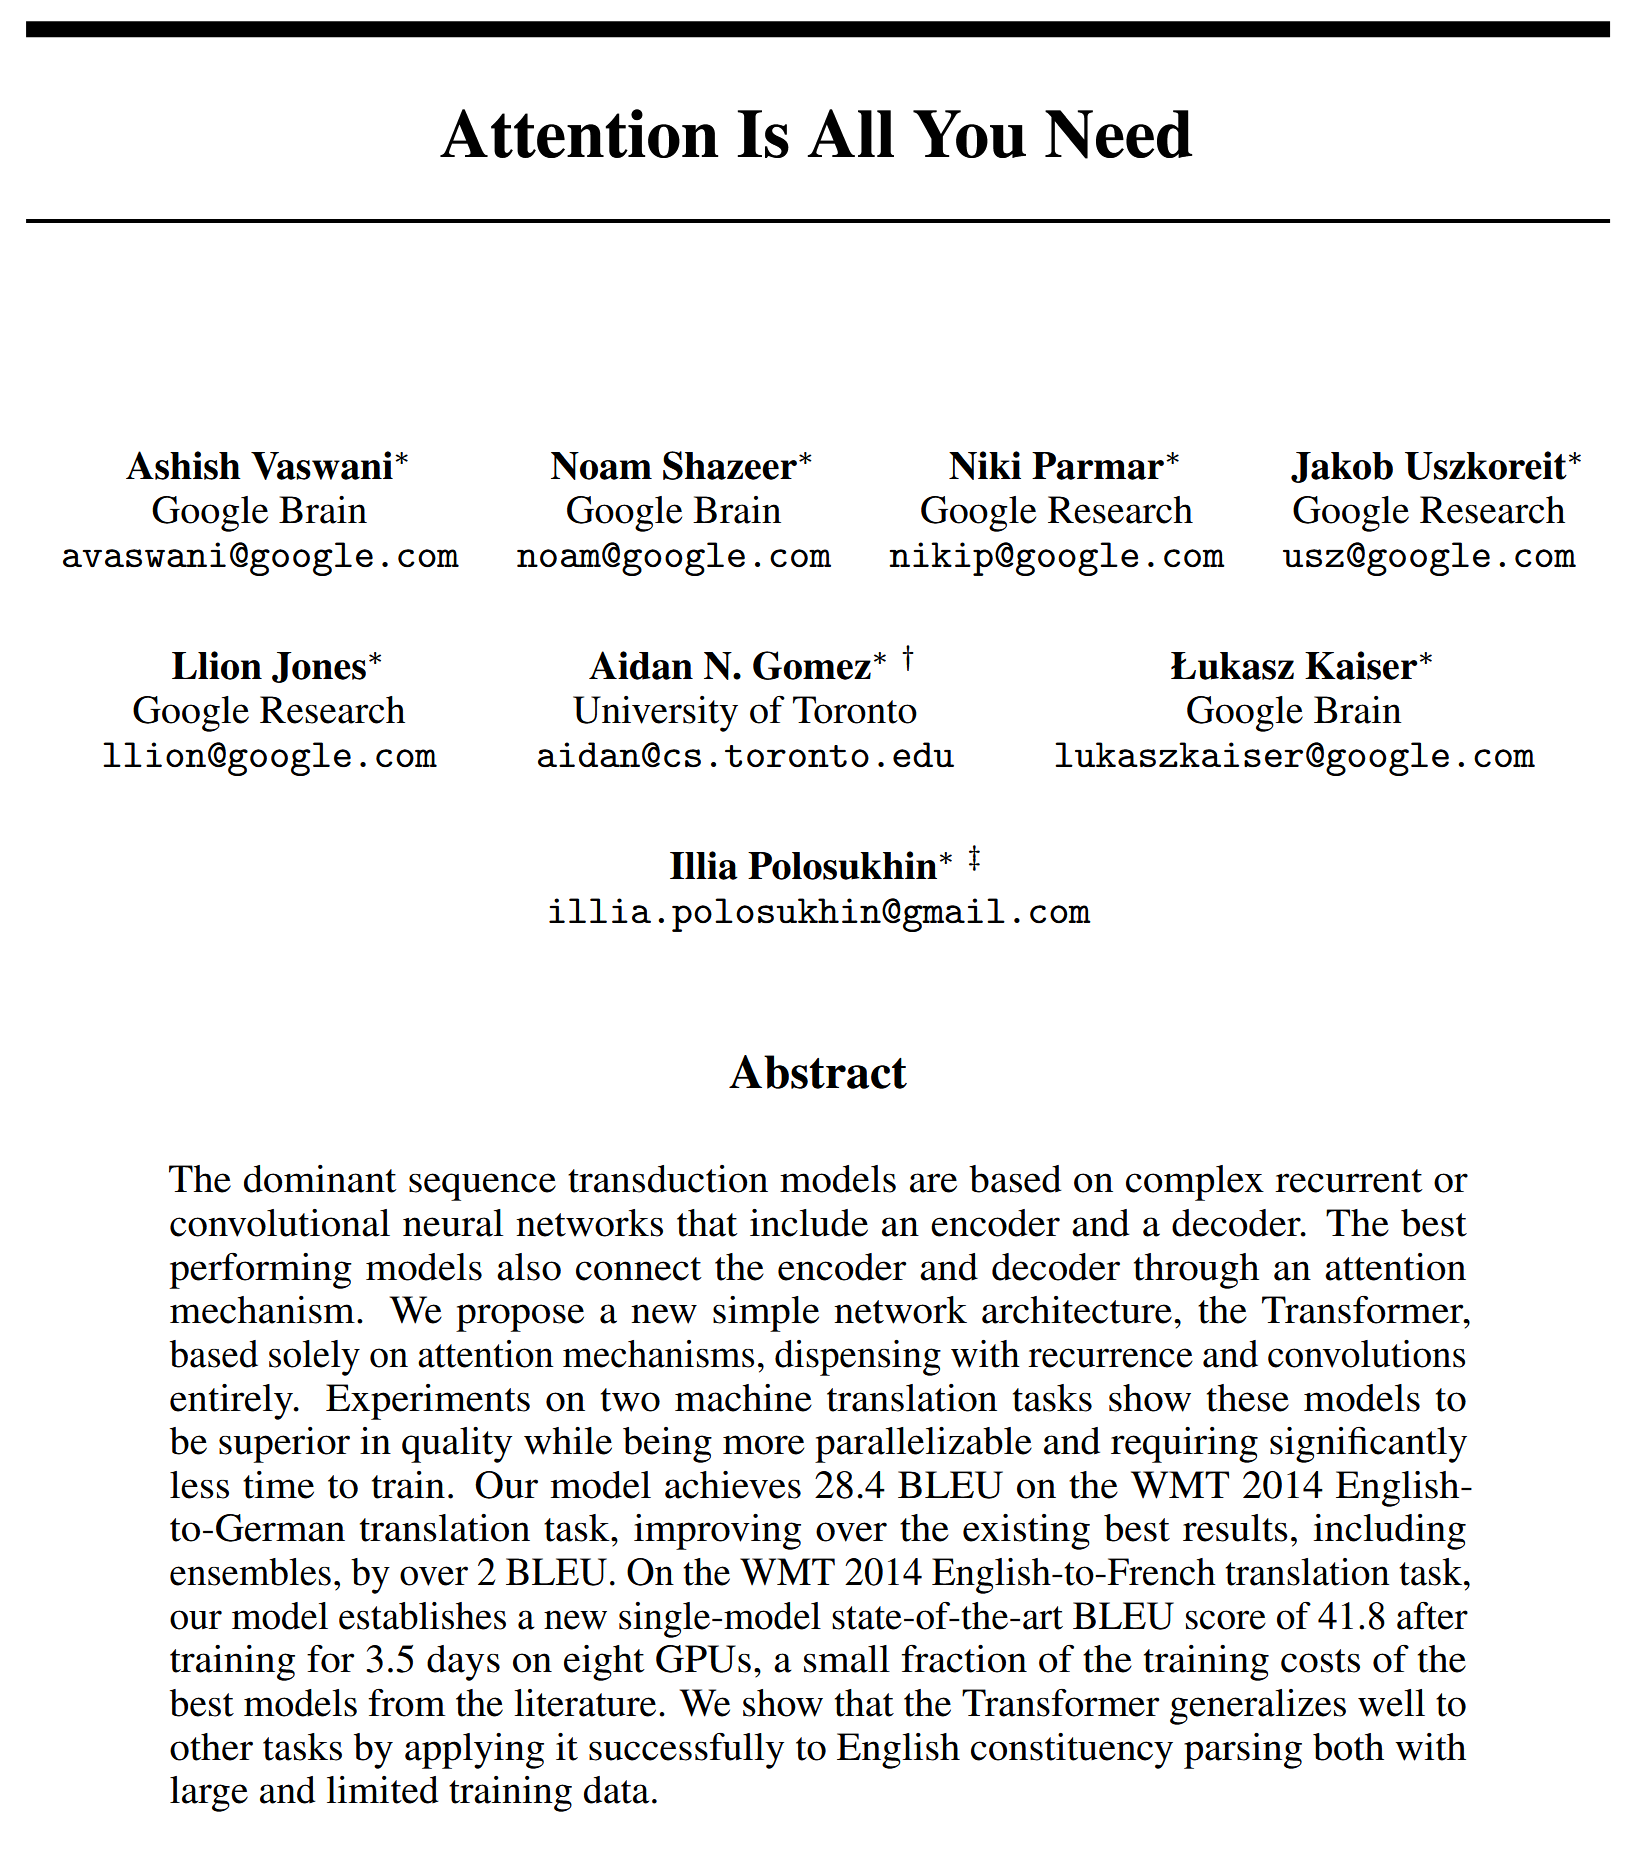

In [1]:
from IPython.display import Image
Image(filename='images/attention_is_all_you_need.png')

## 1, 总体架构

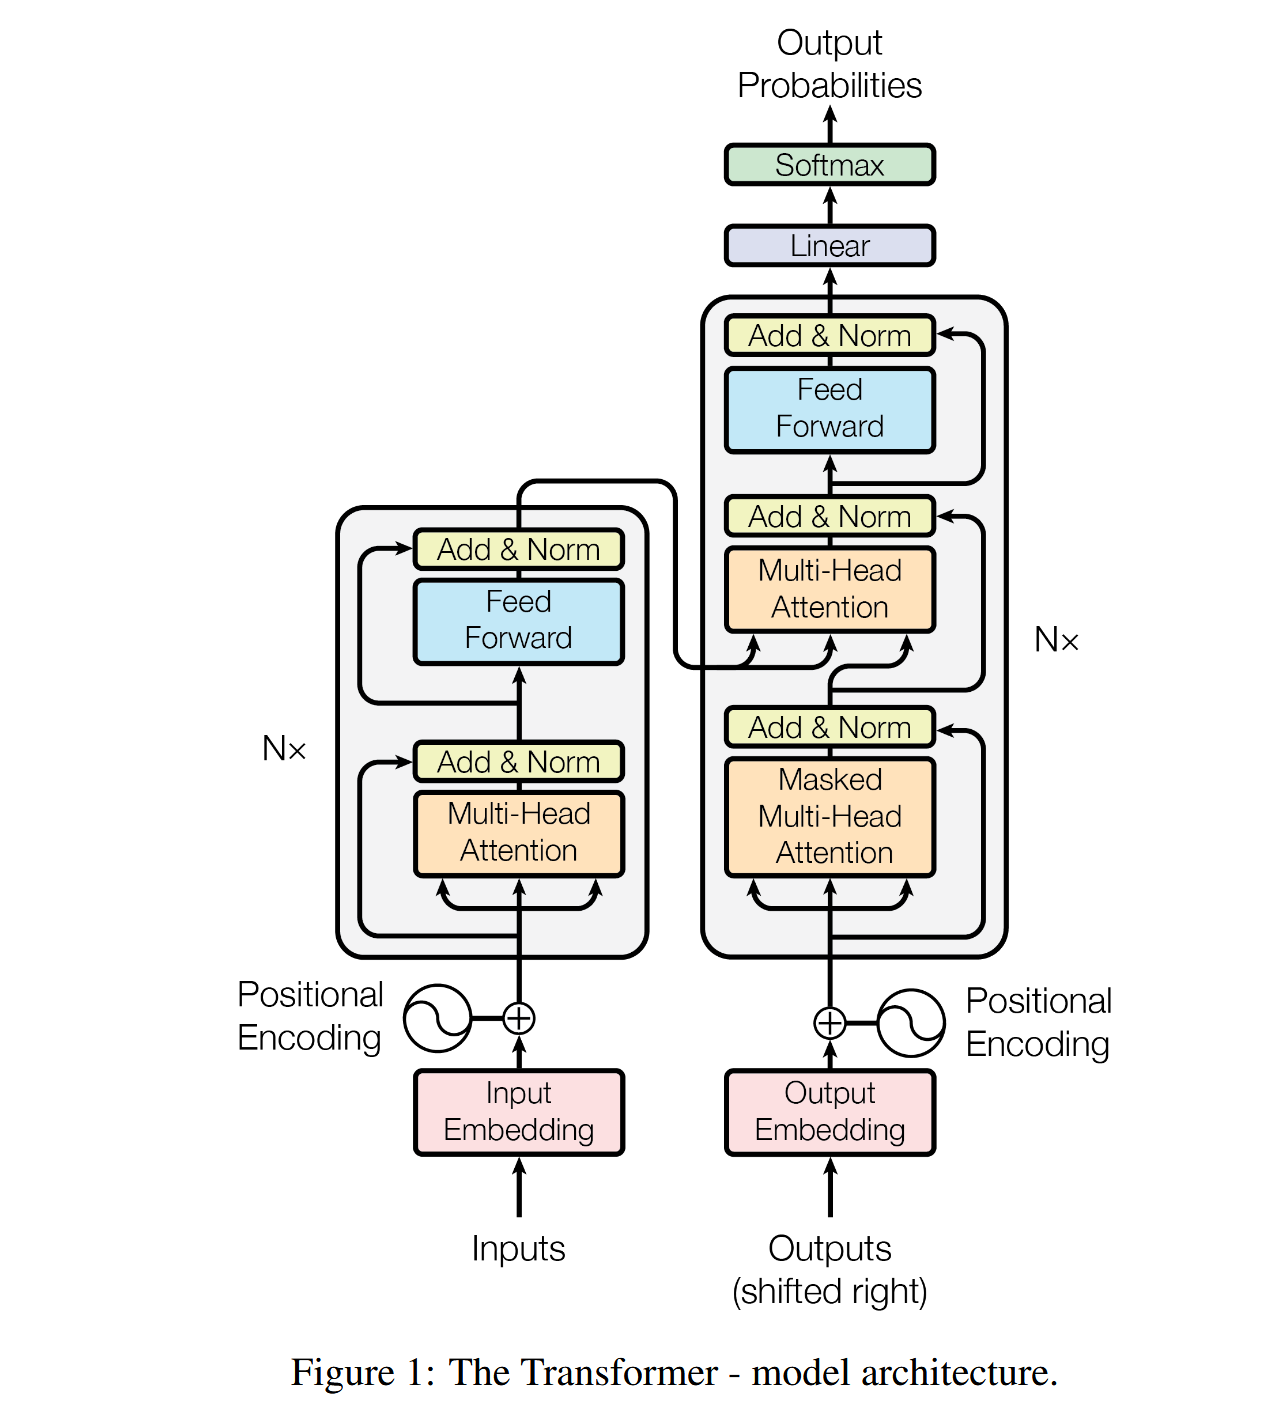

In [2]:
Image(filename='images/model_architecture.png')

### 基本原理
- Input Embedding(输入嵌入)：将输入的单词或字符转换为向量。
- Positionnal Encoding(位置编码)：给每个输入向量添加位置信息，因为 Transformer 模型本身不包含循环或卷积层，无法从输入数据中捕获顺序信息。
- Attention(自注意力机制)：它允许模型在处理序列的每个元素时同时考虑序列中的所有其他元素，从而捕捉元素之间的关系。
- Multi-head Attention(多头自注意力机制)：Transformer 通过并行的多头注意力机制来捕获序列中不同位置的信息，增强模型的学习能力。
- Feed Forward Neural Network(前馈神经网络): 通常包括两个线性变换和一个激活函数（如 ReLU）。
- Residual Connection(残差连接)：帮助在深层网络中解决梯度消失问题。
- Layer Normalization(层归一化)：稳定和加速深层神经网络的训练.（助于避免训练过程中的梯度消失问题，提高模型的稳定性）

Transformer 是深度学习领域的阶段性成果或者说是具有里程碑意义的成果，最初用于处理自然语言处理任务，由 Vaswani 等人在 2017 年提出。目前在Bert和ChatGPT上几乎都有它的影子。它的核心特征是自注意力机制，这使得模型能够有效地处理序列数据中的长距离依赖问题。由于其出色的并行处理能力和优异的性能，Transformer 已成为当今自然语言处理领域的基石技术。

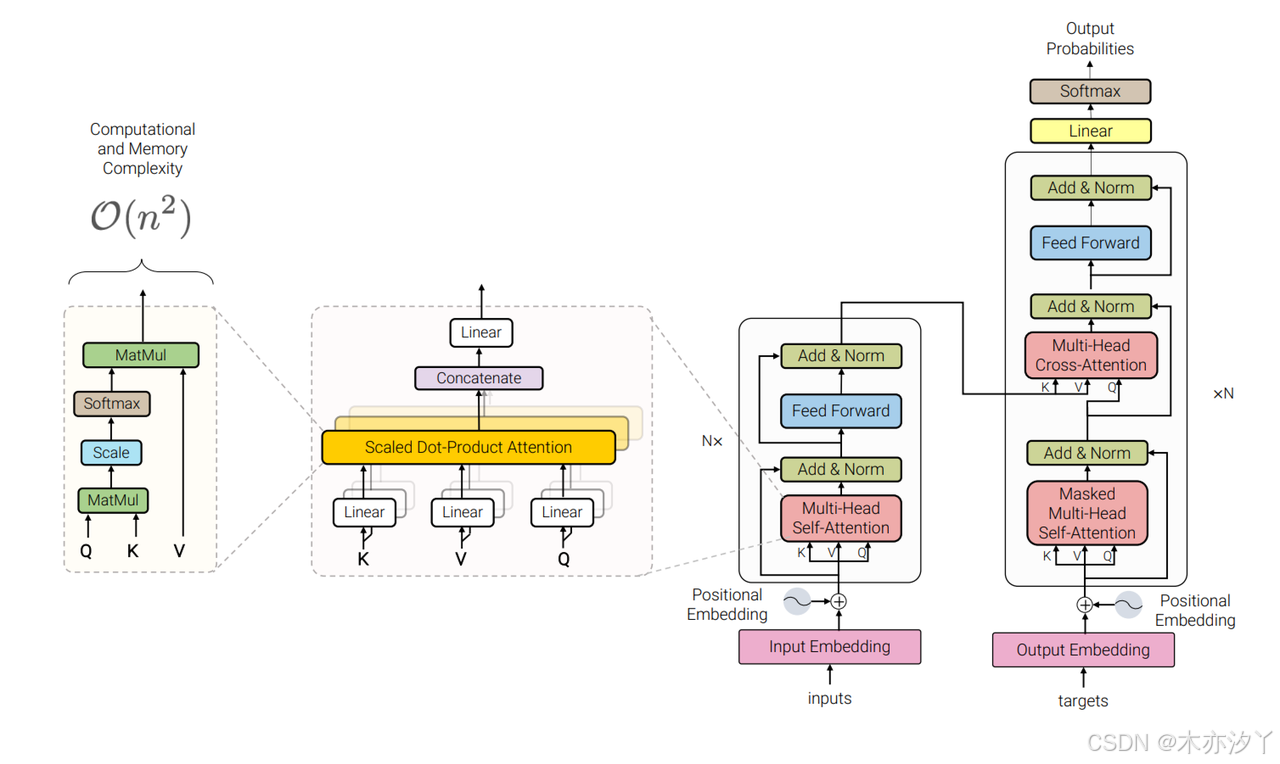

In [3]:
Image(filename='images/model_architecture_detail.png')

In [4]:
import os
from os.path import exists
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.functional import log_softmax, pad
import math, copy, time
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn 
import warnings
import altair as alt
import pandas as pd
# import torchtext.datasets as datasets
# from torchtext.data.functional import to_map_style_dataset
from torch.utils.data import DataLoader
# from torchtext.vocab import build_vocab_from_iterator
# import spacy
import GPUtil
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
seaborn.set_context(context="talk")
%matplotlib inline

In [5]:
# Set to False to skip notebook execution (e.g. for debugging)
warnings.filterwarnings("ignore")
RUN_EXAMPLES = True

In [6]:
def is_interactive_notebook():
    return __name__ == "__main__"


def show_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        return fn(*args)


def execute_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        fn(*args)

## 2, 编码器 Encoder

- 输入嵌入（Input Embedding）
- 位置编码（Positionnal Encoding）
- 多头注意力机制（Multi-head Attention）
- 前馈网络（Feed Forward Neural Network）

### 2.1, 输入嵌入（Input Embedding）

input Embedding （输入嵌入层）: 将输入的单词或者符号转换成固定维度的向量表示，使其能够被模型处理。（因为计算机本身并不能处理文字等信息，需要将其转为向量来处理。）

> 例如：输入句子是 "Hi how are you", input Embedding 层主要是将每个单词映射到长度相等的向量（这里的向量长度是等于3，但实际中一般较大，可以是225、1024等等，也可以自己设定）。
> 如下，这里我们就将单词"Hi"映射为长度为3的向量[0.1, 0.54, 0.29]，[0.1, 0.54, 0.29]被称为嵌入向量。


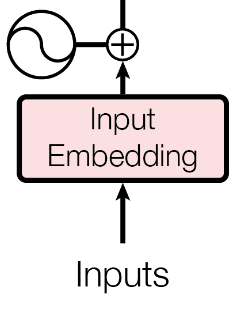

In [7]:
Image(filename='images/input_embedding.png')

In [8]:
class Embeddings(nn.Module):
    def __init__(self, src_vocab_size, d_model):
        super(Embeddings, self).__init__()
        # src_vocab_size：词表大小；d_model：嵌入维度
        self.lut = nn.Embedding(src_vocab_size, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)

### 2.2, 位置编码（Positional Encoding）

由于Transformer模型本身不具备处理序列顺序的能力，但因为在文本信息的处理时，当前单词是跟前后单词有关联系的，因此需要在输入嵌入层（ input Embedding）后加入位置编码（position encoding），以提供位置信息；方便后面的模型训练能够获取文本的位置信息，从而更精准地来进行模型训练。

> **位置编码通常是一组与嵌入向量维度相同的向量，它们通过特定的数学函数生成，并与嵌入向量相加，具体下面会说明。**

位置编码的维度要和嵌入向量的维度一样的原因是因为位置编码是要和嵌入向量的维度相加，因此维度需要一致。

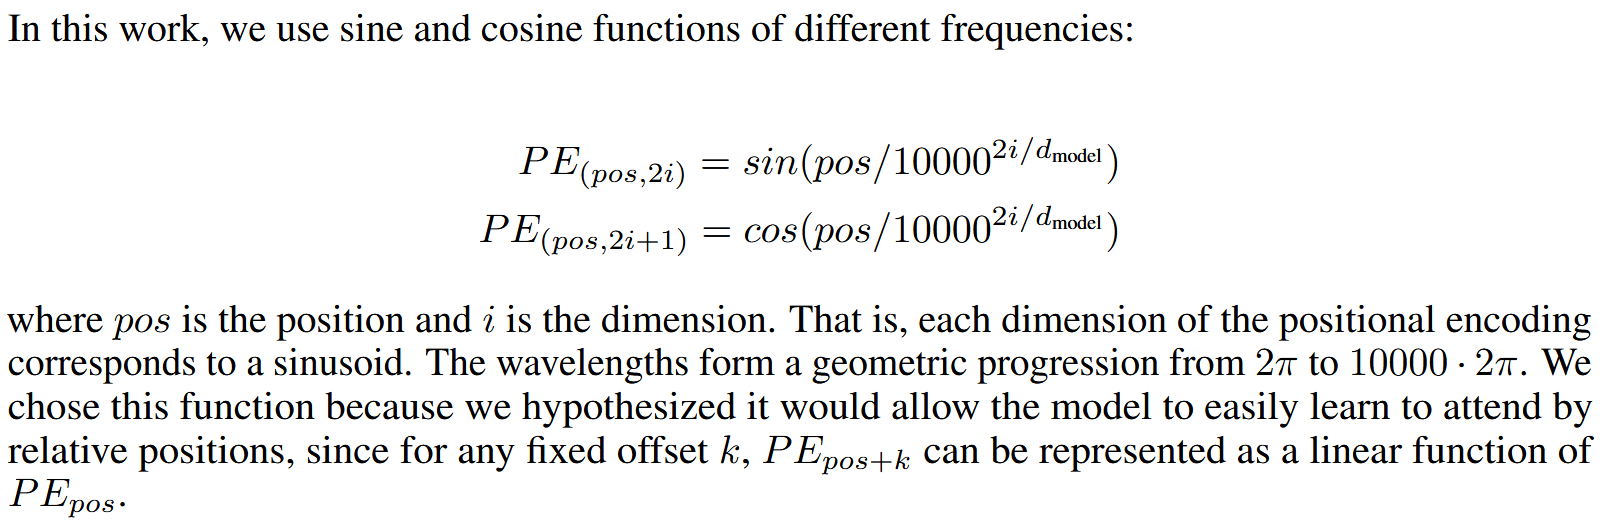

In [9]:
Image(filename='images/positional_encoding_detail.png')

In [10]:
class PositionalEncoding(nn.Module):
    """
    Implement the Positionnal Encoding function.
    位置编码器类的初始化函数
    共有三个参数，分别是
    d_model：词嵌入维度
    dropout: dropout触发比率
    max_len：每个句子的最大长度
    """
    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)

In [11]:
# demo to show positional encoding

def example_positional():
    pe = PositionalEncoding(20, 0)
    y = pe.forward(torch.zeros(1, 100, 20))

    data = pd.concat(
        [
            pd.DataFrame(
                {
                    "embedding": y[0, :, dim],
                    "dimension": dim,
                    "position": list(range(100)),
                }
            )
            for dim in [4, 5, 6, 7]
        ]
    )

    return (
        alt.Chart(data)
        .mark_line()
        .properties(width=800)
        .encode(x="position", y="embedding", color="dimension:N")
        .interactive()
    )

In [12]:
# show_example(example_positional)

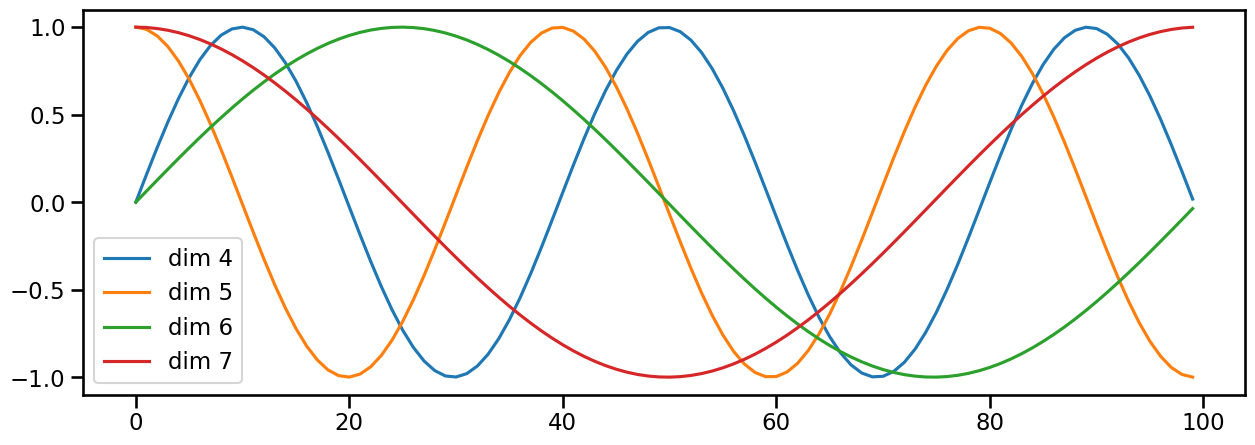

In [13]:
plt.figure(figsize=(15, 5))
pe = PositionalEncoding(20, 0)
y = pe.forward(Variable(torch.zeros(1, 100, 20)))
plt.plot(np.arange(100), y[0, :, 4:8].data.numpy())
plt.legend(["dim %d"%p for p in [4,5,6,7]])
None

### 2.3, 多头自注意力机制（Multi-head Attention）

#### 1, 缩放点积注意力（Scaled Dot-Product Attention）

人类在观察事物时，无法同时仔细观察眼前的一切，只能聚焦到某一个局部。通常我们大脑在简单了解眼前的场景后，能够很快把注意力聚焦到最有价值的局部来仔细观察，从而作出有效判断。或许是基于这样的启发，大家想到了在算法中利用注意力机制。

注意力计算：它需要三个指定的输入Q（query），K（key），V（value），然后通过下面公式得到注意力的计算结果。

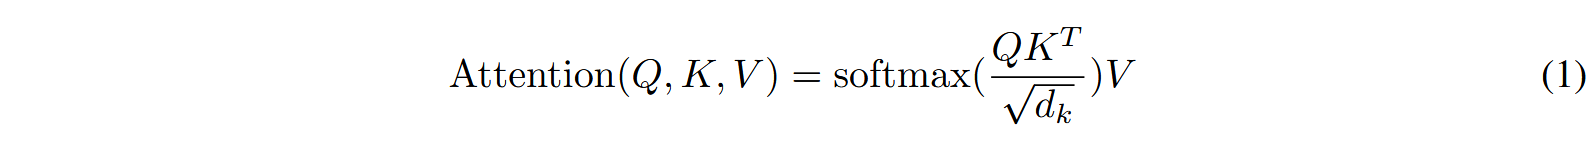

In [14]:
Image(filename='images/attention.png')

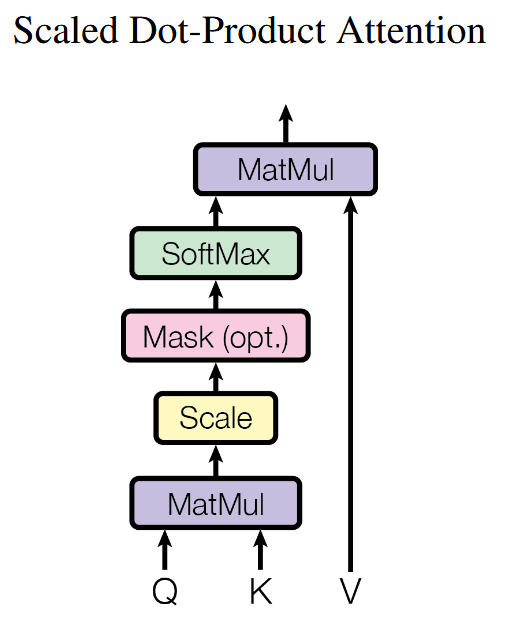

In [15]:
Image(filename='images/scaled_dot-product _attention.png')

注意力函数可以描述为将一个查询和一组键值对映射到一个输出，其中查询、键、值和输出都是向量。
输出是以值的加权和来计算的，其中分配给每个值的权重是通过查询与相应键的兼容函数来计算的。

我们称这种特殊的注意力为 "缩放点积注意力(Scaled Dot-Product Attention)"。
输入包括维数为d_k的查询和键，以及维数为d_v的值。我们计算查询与所有键的点积，将每个点积除以/d_k，然后应用softmax函数获得值的权重。

In [16]:
def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    #首先取query的最后一维的大小，对应词嵌入维度
    d_k = query.size(-1)
    #按照注意力公式，将query与key的转置相乘，这里面key是将最后两个维度进行转置，再除以缩放系数得到注意力得分张量scores
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    #接着判断是否使用掩码张量
    if mask is not None:
        #使用tensor的masked_fill方法，将掩码张量和scores张量每个位置一一比较，如果掩码张量则对应的scores张量用-1e9这个置来替换
        scores = scores.masked_fill(mask == 0, -1e9) 
    #对scores的最后一维进行softmax操作，使用F.softmax方法，这样获得最终的注意力张量
    p_attn = F.softmax(scores, dim = -1)
    #之后判断是否使用dropout进行随机置0
    if dropout is not None:
        p_attn = dropout(p_attn)
    #最后，根据公式将p_attn与value张量相乘获得最终的query注意力表示，同时返回注意力张量
    return torch.matmul(p_attn, value), p_attn

In [17]:
# 两种最常用的注意力函数是加法注意力和点积（乘法）注意力。点积注意力与我们的算法相同，只是没有的缩放因子。加性注意力使用有单个隐藏层的前馈网络来计算兼容函数。
# 虽然二者在理论复杂性上相似，但在实践中点积注意力更快、更节省空间，因其可以使用高度优化的矩阵乘法代码来实现。
# 对于较小的值，两种机制的表现相似，但对于较大的值，加法注意力优于点积注意力，且无需进行缩放（cite）。
# 我们认为，对于较大的值，点积的数量级会变大，从而会将 softmax 函数推入梯度极小的区域 
# 注：为说明点积变大的原因，假设 q 和 k 的分量是独立随机变量，均值为 0 ，方差为 1 。那么它们点积的均值为 0 ，方差为 。为了抵消这种影响，我们将点积缩放倍。

#### 2, 多头注意力机制（Multi-head Attention）

刚刚介绍了attention机制，即搭建EncoderLayer时候所使用的Attention模块，实际使用的是多头注意力，可以简单理解为多个注意力模块组合在一起。

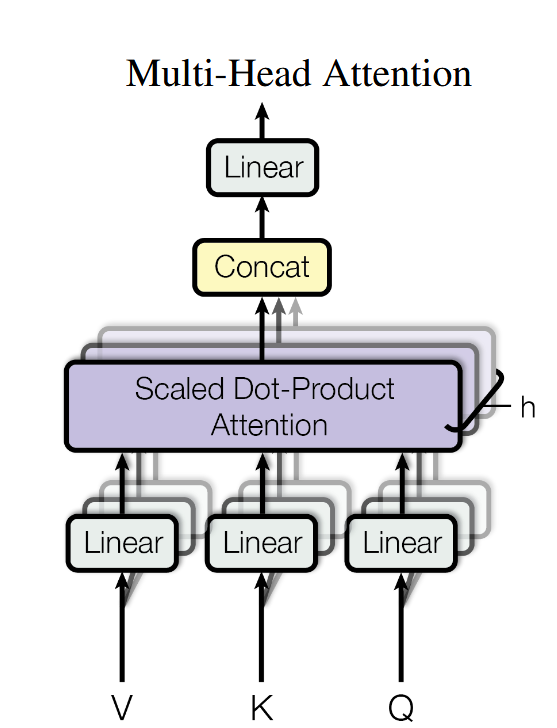

In [18]:
Image(filename='images/multi-head_attention_fig.png')

In [19]:
# 多头注意力允许模型在不同位置共同关注来自不同表征子空间的信息, 而在单注意力头的情况下,平均化会抑制这一点

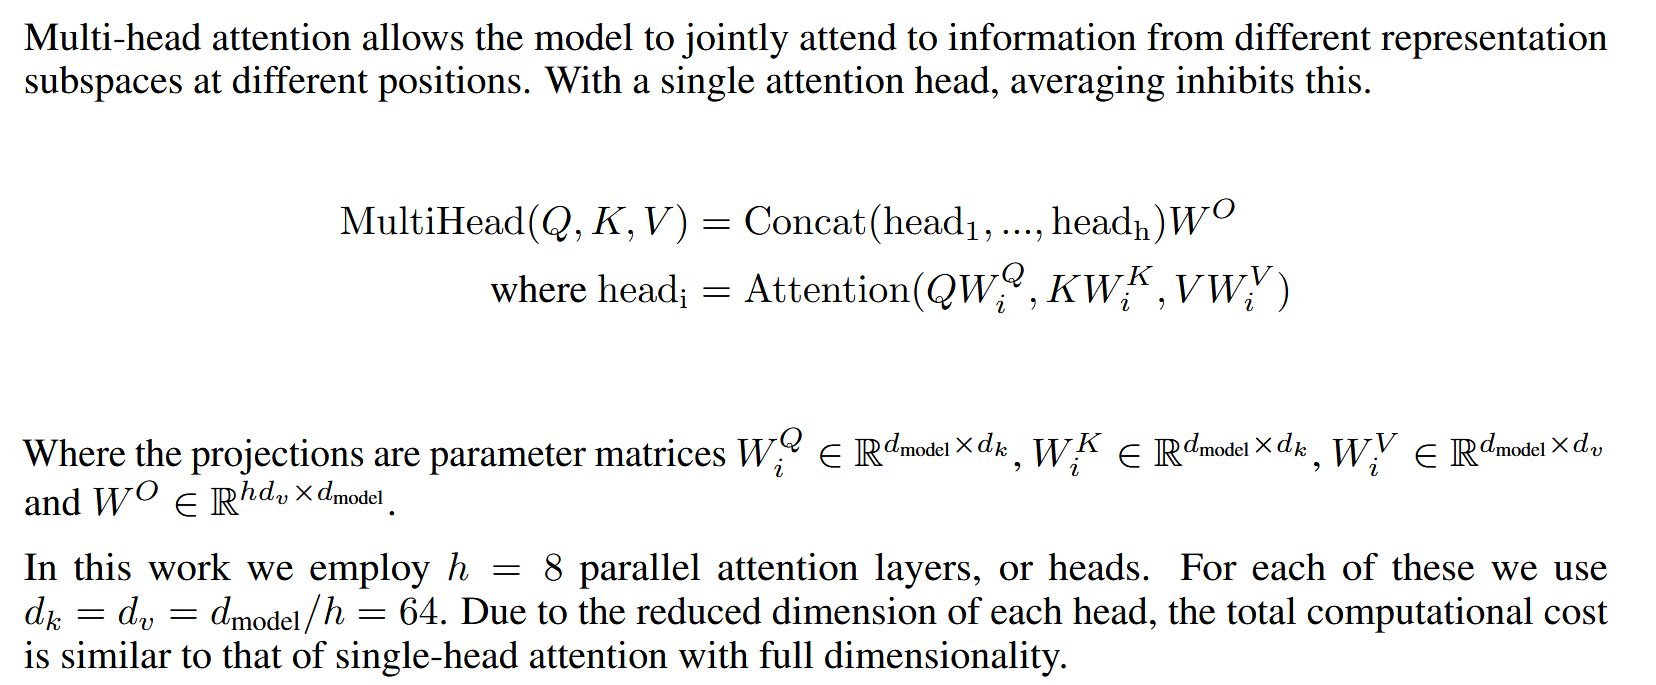

In [20]:
Image(filename='images/multi-head_attention.png')

In [21]:
class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        #在类的初始化时，会传入三个参数，h代表头数，d_model代表词嵌入的维度，dropout代表进行dropout操作时置0比率，默认是0.1
        super(MultiHeadedAttention, self).__init__()
        #在函数中，首先使用了一个测试中常用的assert语句，判断h是否能被d_model整除，这是因为我们之后要给每个头分配等量的词特征，也就是embedding_dim/head个
        assert d_model % h == 0
        #得到每个头获得的分割词向量维度d_k
        self.d_k = d_model // h
        #传入头数h
        self.h = h
        
        #创建linear层，通过nn的Linear实例化，它的内部变换矩阵是embedding_dim x embedding_dim，然后使用，为什么是四个呢，这是因为在多头注意力中，Q,K,V各需要一个，最后拼接的矩阵还需要一个，因此一共是四个
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        #self.attn为None，它代表最后得到的注意力张量，现在还没有结果所以为None
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)
        
    def forward(self, query, key, value, mask=None):
        #前向逻辑函数，它输入参数有四个，前三个就是注意力机制需要的Q,K,V，最后一个是注意力机制中可能需要的mask掩码张量，默认是None
        if mask is not None:
            # Same mask applied to all h heads.
            #使用unsqueeze扩展维度，代表多头中的第n头
            mask = mask.unsqueeze(1)
        #接着，我们获得一个batch_size的变量，他是query尺寸的第1个数字，代表有多少条样本
        nbatches = query.size(0)
        
        # 1) Do all the linear projections in batch from d_model => h x d_k 
        # 首先利用zip将输入QKV与三个线性层组到一起，然后利用for循环，将输入QKV分别传到线性层中，做完线性变换后，开始为每个头分割输入，这里使用view方法对线性变换的结构进行维度重塑，多加了一个维度h代表头，这样就意味着每个头可以获得一部分词特征组成的句子，其中的-1代表自适应维度，计算机会根据这种变换自动计算这里的值，然后对第二维和第三维进行转置操作，为了让代表句子长度维度和词向量维度能够相邻，这样注意力机制才能找到词义与句子位置的关系，从attention函数中可以看到，利用的是原始输入的倒数第一和第二维，这样我们就得到了每个头的输入
        query, key, value = \
            [l(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
             for l, x in zip(self.linears, (query, key, value))]
 
        # 2) Apply attention on all the projected vectors in batch. 
        # 得到每个头的输入后，接下来就是将他们传入到attention中，这里直接调用我们之前实现的attention函数，同时也将mask和dropout传入其中
        x, self.attn = attention(query, key, value, mask=mask, 
                                 dropout=self.dropout)
 
        # 3) "Concat" using a view and apply a final linear. 
        # 通过多头注意力计算后，我们就得到了每个头计算结果组成的4维张量，我们需要将其转换为输入的形状以方便后续的计算，因此这里开始进行第一步处理环节的逆操作，先对第二和第三维进行转置，然后使用contiguous方法。这个方法的作用就是能够让转置后的张量应用view方法，否则将无法直接使用，所以，下一步就是使用view重塑形状，变成和输入形状相同。  
        x = x.transpose(1, 2).contiguous() \
             .view(nbatches, -1, self.h * self.d_k)
        #最后使用线性层列表中的最后一个线性变换得到最终的多头注意力结构的输出
        return self.linears[-1](x)

### 2.4, 层归一化（Layer Norm）

> 归一化层的作用：它是所有深层网络模型都需要的标准网络层，因为随着网络层数的增加，通过多层的计算后输出可能开始出现过大或过小的情况，这样可能会导致学习过程出现异常，模型可能收敛非常慢。因此都会在一定层后接归一化层进行数值的归一化，使其特征数值在合理范围内。

简单地说：
  - 批归一化是跨样本对每个特征分别归一化，每个特征的归一化基于整个批次的统计数据。
  - 层归一化是在每个样本内部进行的，每个样本的所有特征都根据该样本的统计数据进行归一化。

Transformer中主要利用layer-normal层归一化，而并不是批归一化，这有助于避免训练过程中的梯度消失问题，提高模型的稳定性。

使用层归一化的原因在于：在处理自然语言任务时，序列的长度通常是变化的。层归一化因为是对单个样本中的所有特征进行归一化，所以能够更好地处理这种可变长度的情况。而批归一化则依赖于整个批次的数据统计，这在处理小批次或可变长度的序列时可能不太有效。此外，Transformer模型特别依赖于捕捉长期依赖关系（即序列中相隔较远的元素之间的关系），而层归一化有助于缓解训练过程中可能出现的梯度消失问题，从而更有效地学习这些长期依赖关系。

什么时候使用：在残差连接（Residual Connection）之后，Transformer模型中的每个子层都伴随一个残差连接，然后紧接着一个层归一化操作。具体来说，对于每个子层（例如自注意力或前馈网络），输入首先通过子层自身，然后将子层的输出与输入进行相加（残差连接），最后对这个相加的结果进行层归一化。


In [22]:
class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."
    def __init__(self, feature_size, eps=1e-6):
        #初始化函数有两个参数，一个是features,表示词嵌入的维度,另一个是eps它是一个足够小的数，在规范化公式的分母中出现,防止分母为0，默认是1e-6。
        super(LayerNorm, self).__init__()
        #根据features的形状初始化两个参数张量a2，和b2，第一初始化为1张量，也就是里面的元素都是1，第二个初始化为0张量，也就是里面的元素都是0，这两个张量就是规范化层的参数。因为直接对上一层得到的结果做规范化公式计算，将改变结果的正常表征，因此就需要有参数作为调节因子，使其即能满足规范化要求，又能不改变针对目标的表征，最后使用nn.parameter封装，代表他们是模型的参数
        self.a_2 = nn.Parameter(torch.ones(feature_size))
        self.b_2 = nn.Parameter(torch.zeros(feature_size))
        #把eps传到类中
        self.eps = eps
 
    def forward(self, x):
        #输入参数x代表来自上一层的输出，在函数中，首先对输入变量x求其最后一个维度的均值，并保持输出维度与输入维度一致，接着再求最后一个维度的标准差，然后就是根据规范化公式，用x减去均值除以标准差获得规范化的结果。
        #最后对结果乘以我们的缩放参数，即a2,*号代表同型点乘，即对应位置进行乘法操作，加上位移参b2，返回即可
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

### 2.5, 残差连接（Residual Connection）

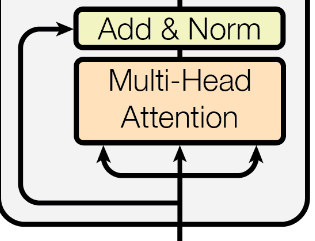

In [23]:
Image(filename='images/residual.png')

在上面残差连接，主要是将多头注意力机制的输出向量加到原始输入向量（添加过位置编码后的Embedding向量）上，在经过层归一化。

每个子层的输出都是 LayerNorm(x+Sublayer(x)) ，其中 Sublayer(x) 是子层本身实现的函数。我们对每个子层的输出进行 dropout 操作 （cite），然后再将其与子层的输入相加并进行归一化（即 Layer Normalization）。

为了方便这些残差连接，模型中的所有子层以及嵌入层都会产生维数为 d_{model}=512 的输出。

In [24]:
class SublayerConnection(nn.Module):
    """ 
    实现子层连接结构的类
    """
    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    # sublayer 添加了位置编码后的x + 多头注意力输出的结果
    def forward(self, x, sublayer):
        # 原paper的方案
        return self.norm(x + self.dropout(sublayer(x)))

### 2.6, 前馈网络（Feed Forward Nerual Network）

其实在Transformer原文中 Feed Forward 的全称是 Position-wise Feed-Forward Networks (点对点前馈神经网络，简称FFN)。

其实他就是两个全连接层：第一个全连接层将输入的维度扩展（例如，从512维扩展到2048维），接着是一个激活函数（通常是ReLU或GELU），然后是第二个全连接层，将维度从扩展的维度缩减回原始维度（例如，从2048维缩减回512维）。

前馈网络处理完后，先对其进行一个残差连接，再进行层归一化处理。


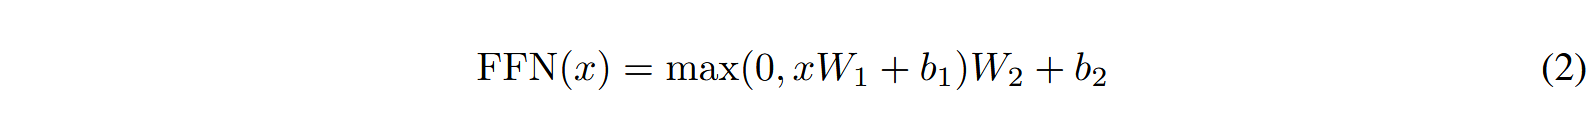

In [25]:
Image(filename='images/position-wise_FFN.png')

In [26]:
class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        #初始化函数有三个输入参数分别是d_model，d_ff，
        # 和dropout=0.1，第一个是线性层的输入维度也是第二个线性层的输出维度，因为我们希望输入通过前馈全连接层后输入和输出的维度不变，
        # 第二个参数d_ff就是第二个线性层的输入维度和第一个线性层的输出，最后一个是dropout置0比率。
        # 512-2048 -- 2048-512 维度输出
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)
 
    def forward(self, x):
        #输入参数为x，代表来自上一层的输出，首先经过第一个线性层，然后使用F中的relu函数进行激活，之后再使用dropout进行随机置0，最后通过第二个线性层w2，返回最终结果
        return self.w_2(self.dropout(F.relu(self.w_1(x))))

### 2.7, 编码器（Encoder）

以上就是编码器部分的所有组件，编码器的作用主要是为了将输入编码为连续表示，并带有注意力信息；有助于帮助解码器在解码过程中关注输入中的重要词汇。当然，需要注意的是，可以将编码器堆叠 N 次，以进一步编码信息，其中每一层都有机会学习不同的注意力表示，从而提高Transformer的预测能力；

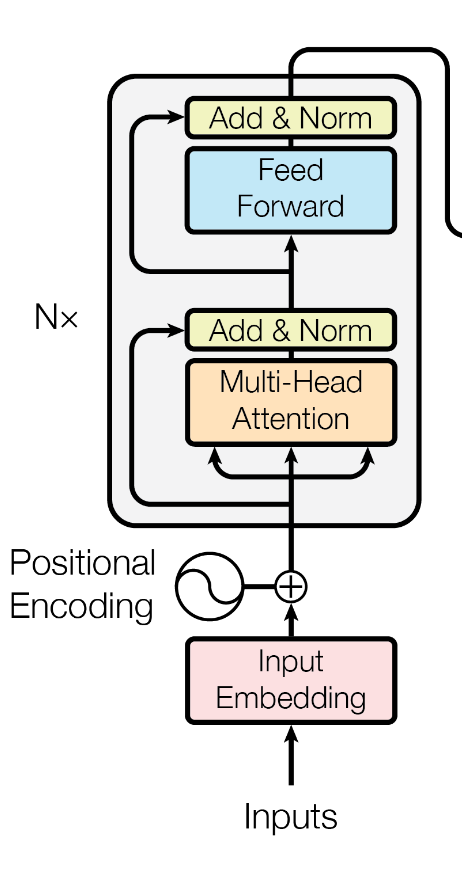

In [27]:
Image(filename='images/encoder.png')

##### 编码器流程

模型的编码器由N个相同的层堆叠在一起(原始论文中N=6)，每一层又有两个子层。
- 第一个子层是一个Multi-Head Self Attention(多头自注意力机制)，
- 第二个子层是一个简单的position-wise feed-forward network(FFN)(逐位全连接前馈网络)。

两个子层都添加了一个残差连接(residual connection)+ 层归一化(layer normalization)的操作。

编码器作用是用于对输入进行特征提取, 为解码环节提供有效的语义信息。

**整体来看编码器由6个编码器层简单堆叠而成，代码如下：**

#### Clone函数

In [28]:
# 定义一个clones函数，来更方便的将某个结构复制若干份
def clones(module, N):
    "Produce N identical layers."
    return nn.ModuleList([copy.deepcopy(module) for _ in range(N)])

#### Encoder函数

In [29]:
class Encoder(nn.Module):
    """
    Encoder
    The encoder is composed of a stack of N=6 identical layers.
    """
    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        # 调用时会将编码器层传进来，我们简单克隆N分，叠加在一起，组成完整的Encoder
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)
        
    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)

#### 编码器层

每个编码器层由两个子层连接结构组成：
- 第一个子层包括一个多头自注意力层（Multi-head Attention）；
- 第二个子层包括一个逐位前馈全连接层(FFN)；我们在每两个子层的前后都采用了残差连接(Residual Connection)，然后进行层归一化(Layer Norm)。

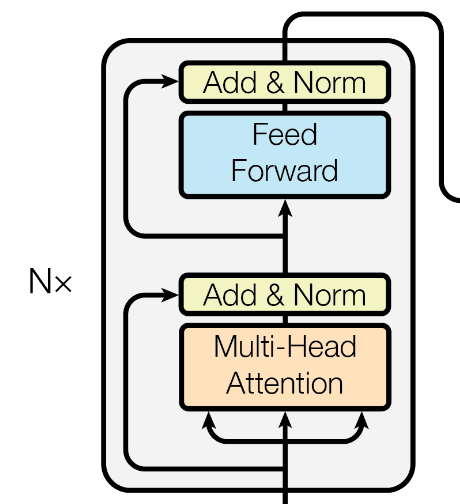

In [30]:
Image(filename='images/encoder_layer.png')

In [31]:
class EncoderLayer(nn.Module):
    "EncoderLayer is made up of two sublayer: self-attn and feed forward"                                                                                                         
    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2) # Add & Norm 残差网络+层归一化
        self.size = size   # embedding's dimention of model, 默认512
 
    def forward(self, x, mask):
        # attention sub layer
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask)) # 第一个Add & Norm
        # feed forward sub layer
        z = self.sublayer[1](x, self.feed_forward)  # 第二个Add & Norm
        return z

## 3, 解码器 Decoder


Decoderde的任务是生成文本序列，需要注意的是解码器是自回归的，Decoder部分主要包括：
- Masked Multi-Head Attention 具有掩码的多头注意力机制
- Multi-Head Attention 多头注意力机制
- Feed Forward 前馈网络 / 分类器。

### 3.1, 输出嵌入 Output Embedding 
### 3.2, 位置编码 Positional Encoding

在Decoder部分，也可以看到有Embedding 和 Positional Encoding层，如下图所示。

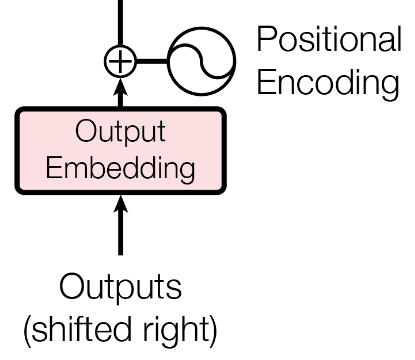

In [32]:
Image(filename='images/output_embedding.png')

在训练阶段，目标序列是已知的，整个已知的目标序列（包括起始符号，通常是“<sos>”）一次性转换为索引，然后通过嵌入层转换为密集的向量表示。然后，这些嵌入向量会被加上位置编码，以引入序列中单词的位置信息。加上位置编码的嵌入向量作为解码器的输入，用于模型的训练过程。


> 这里的目标序列可以理解为输入的序列，就说输入的文本数据

### 3.3, 具有掩码的多头注意力机制 Masked Multi-Head Attention

由于在Decoder中的Embedding层 和 Positional Encoding层是对目标序列所有单词都进行了嵌入，但我们利用Transformer模型在生成序列时，是一个个单词往外蹦的；
那么，确保在预测序列的特定位置时，模型只能使用到该位置之前的信息，其后面的信息就不能被注意力机制看到（也就是保证模型在训练的时候只能看到当前单词之前的单词，不能看到之后的），从而防止信息泄露。就需要想办法去遮挡后面的信息。

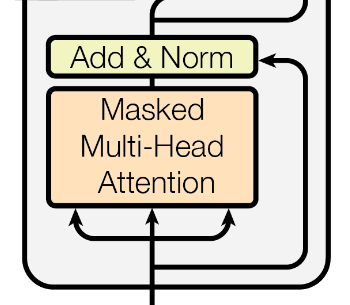

In [33]:
Image(filename='images/masked_multi-head_attention.png')

为了防止解码器看到未来的信息，就需要在已得到的注意力分数矩阵式加上一个mask机制（或者叫mask矩阵），如下图所示。

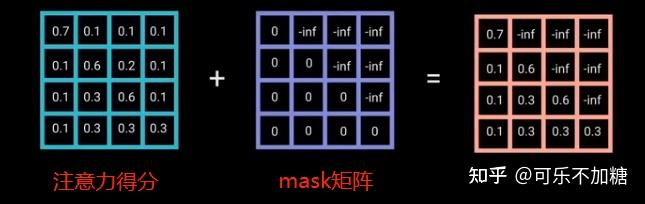

In [34]:
Image(filename='images/mask1.jpg')

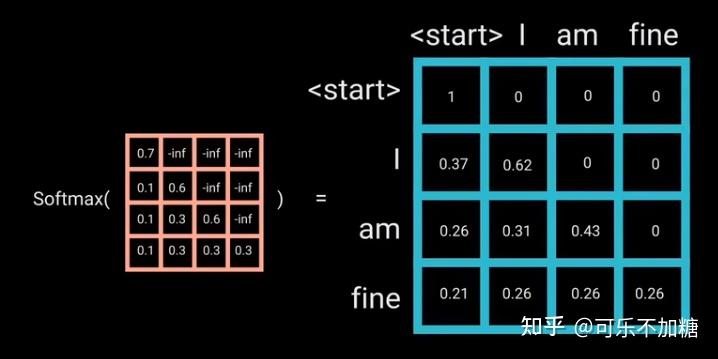

In [35]:
Image(filename='images/mask2.jpg')

### 3.4, 多头注意力机制

这里的多头注意力机制的原理是和Encoder部分一样的，具体计算过程可以参考Encoder部分。

但需要注意的是，这一部分主要是将解码器当前生成的序列与原始输入序列（经过编码器处理的）联系起来，用于生成下一个目标单词。
这部分的注意力机制作用主要有两个：

- 连接源序列和目标序列：通过关注编码器的输出，解码器可以根据需要从源序列中提取相关的上下文信息；
- 动态关注不同部分：同时，在解码过程中，模型可能会选择关注输入序列的不同部分。

### 3.5, 前馈网络 Feed Forward

参考Encoder部分的 Feed Forward 。

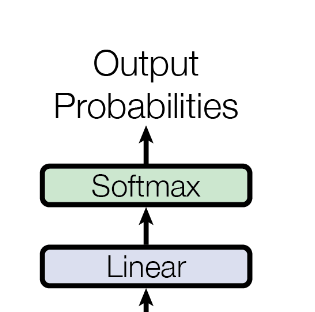

In [36]:
Image(filename='images/linear_output.png')

### 3.6, 生成序列停止

不知道大家有没有注意一个问题：Transformer模型并没有定义结果的输出长度，那整个序列就会一直生成下去。那程序什么时候停止呢？

就是在模型输出"<eos>"（代表“end of sequence”）时停止。

In [37]:
#将线性层和softmax计算层一起实现，因为二者的共同目标是生成最后的结构
#因此把类的名字叫做Generator，生成器类
class Generator(nn.Module):
    "Define standard linear + softmax generation step."
    def __init__(self, d_model, vocab):
        #初始化函数的输入参数有两个，d_model代表词嵌入维度，vocab.size代表词表大小
        super(Generator, self).__init__()
        #首先就是使用nn中的预定义线性层进行实例化，得到一个对象self.proj等待使用
        #这个线性层的参数有两个，就是初始化函数传进来的两个参数：d_model，vocab_size
        self.proj = nn.Linear(d_model, vocab)
 
    def forward(self, x):
        #前向逻辑函数中输入是上一层的输出张量x,在函数中，首先使用上一步得到的self.proj对x进行线性变化,然后使用F中已经实现的log_softmax进行softmax处理。
        return F.log_softmax(self.proj(x), dim=-1)

### 3.7, 解码器（Decoder）

每个解码器层由三个子层连接结构组成，
- 第一个子层连接结构包括一个掩码多头自注意力子层，
- 第二个子层连接结构包括一个多头注意力子层，
- 第三个子层连接结构包括一个逐位前馈全连接子层。

与编码器类似，在解码器的每个子层间都是用的残差连接和层归一化。

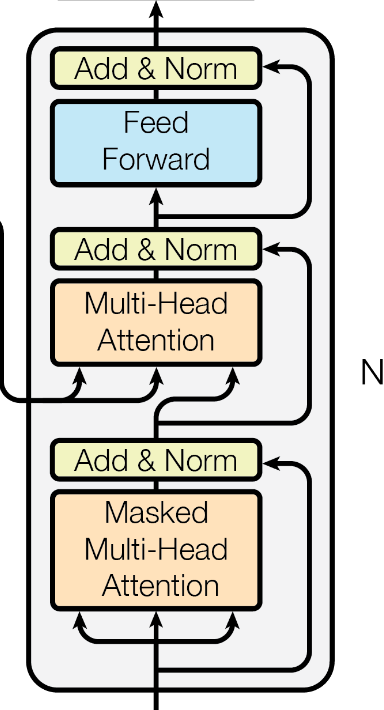

In [38]:
Image(filename='images/decoder.png')

解码器层中的各个子模块,如多头注意力机制,前馈全连接层,残差连接, 归一化层都与编码器中的实现相同

有一个细节需要注意, 第一个子层的多头注意力机制和编码器中的实现完全一致,但是参数mask的规则不同
第二个子层,它的多头注意力模块中, query来自上一个子层,key和value来自编码器的输出
可以这样理解,就是第二层负责,利用解码器已经预测出的信息作为query, 去编码器提取的各种特征中,查找相关信息并融合到当前特征中,来完成预测

In [39]:
#使用DecoderLayer的类实现解码器层
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward (defined below)"
    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        #初始化函数的参数有5个，分别是size，代表词嵌入的维度大小，同时也代表解码器的尺寸，第二个是self_attn，多头自注意力对象，也就是说这个注意力机制需要Q=K=V，第三个是src_attn,多头注意力对象，这里Q!=K=V，第四个是前馈全连接层对象，最后就是dropout置0比率
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        #按照结构图使用clones函数克隆三个子层连接对象
        self.sublayer = clones(SublayerConnection(size, dropout), 3)
 
    def forward(self, x, memory, src_mask, tgt_mask):
        #forward函数中的参数有4个，分别是来自上一层的输入x，来自编码器层的语义存储变量memory，以及源数据掩码张量和目标数据掩码张量，将memory表示成m之后方便使用。
        "Follow Figure 1 (right) for connections."
        m = memory
        #将x传入第一个子层结构，第一个子层结构的输入分别是x和self-attn函数，因为是自注意力机制，所以Q,K,V都是x，最后一个参数时目标数据掩码张量，这时要对目标数据进行遮掩，因为此时模型可能还没有生成任何目标数据。
        #比如在解码器准备生成第一个字符或词汇时，我们其实已经传入了第一个字符以便计算损失，但是我们不希望在生成第一个字符时模型能利用这个信息，因此我们会将其遮掩，同样生成第二个字符或词汇时，模型只能使用第一个字符或词汇信息，第二个字符以及之后的信息都不允许被模型使用。
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        
        #接着进入第二个子层，这个子层中常规的注意力机制，q是输入x;k,v是编码层输出memory，同样也传入source_mask，但是进行源数据遮掩的原因并非是抑制信息泄露，而是遮蔽掉对结果没有意义的padding。
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        
        #最后一个子层就是前馈全连接子层，经过它的处理后就可以返回结果，这就是我们的解码器结构
        return self.sublayer[2](x, self.feed_forward)

### 3.8, 掩码 Mask

掩码：掩代表遮掩，码就是我们张量中的数值，它的尺寸不定，里面一般只有0和1；代表位置被遮掩或者不被遮掩。

掩码的作用：在transformer中，掩码主要的作用有两个：
- 一个是屏蔽掉无效的padding区域，
- 一个是屏蔽掉来自“未来”的信息。Encoder中的掩码主要是起到第一个作用，Decoder中的掩码则同时发挥着两种作用。

屏蔽掉无效的padding区域：我们训练需要组batch进行，就以机器翻译任务为例，一个batch中不同样本的输入长度很可能是不一样的，此时我们要设置一个最大句子长度，然后对空白区域进行padding填充，而填充的区域无论在Encoder还是Decoder的计算中都是没有意义的，因此需要用mask进行标识，屏蔽掉对应区域的响应。

屏蔽掉来自未来的信息：我们已经学习了attention的计算流程，它是会综合所有时间步的计算的，那么在解码的时候，就有可能获取到未来的信息，这是不行的。因此，这种情况也需要我们使用mask进行屏蔽。

In [40]:
def subsequent_mask(size):
    #生成向后遮掩的掩码张量，参数size是掩码张量最后两个维度的大小，它最后两维形成一个方阵
 
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    
    #然后使用np.ones方法向这个形状中添加1元素，形成上三角阵
    subsequent_mask = np.triu(np.ones(attn_shape), k=1).astype('uint8')
 
    #最后将numpy类型转化为torch中的tensor，内部做一个1- 的操作。这个其实是做了一个三角阵的反转，subsequent_mask中的每个元素都会被1减。
    #如果是0，subsequent_mask中的该位置由0变成1
    #如果是1，subsequect_mask中的该位置由1变成0
    return torch.from_numpy(subsequent_mask) == 0

## 4, 模型构建
根据Transformer总体架构图进行拼接各个模块，搭建出整个网络的结构：

模型结构大致分为Encoder(编码器)和Decoder(解码器)两个部分，分别对应上图的左右两部分。 

模型的输入由Input Embedding和Positional Encoding(位置编码)两部分组合而成。

模型的输出由Decoder的输出简单经过Linear和Softmax得到。

### 4.1 编码与解码

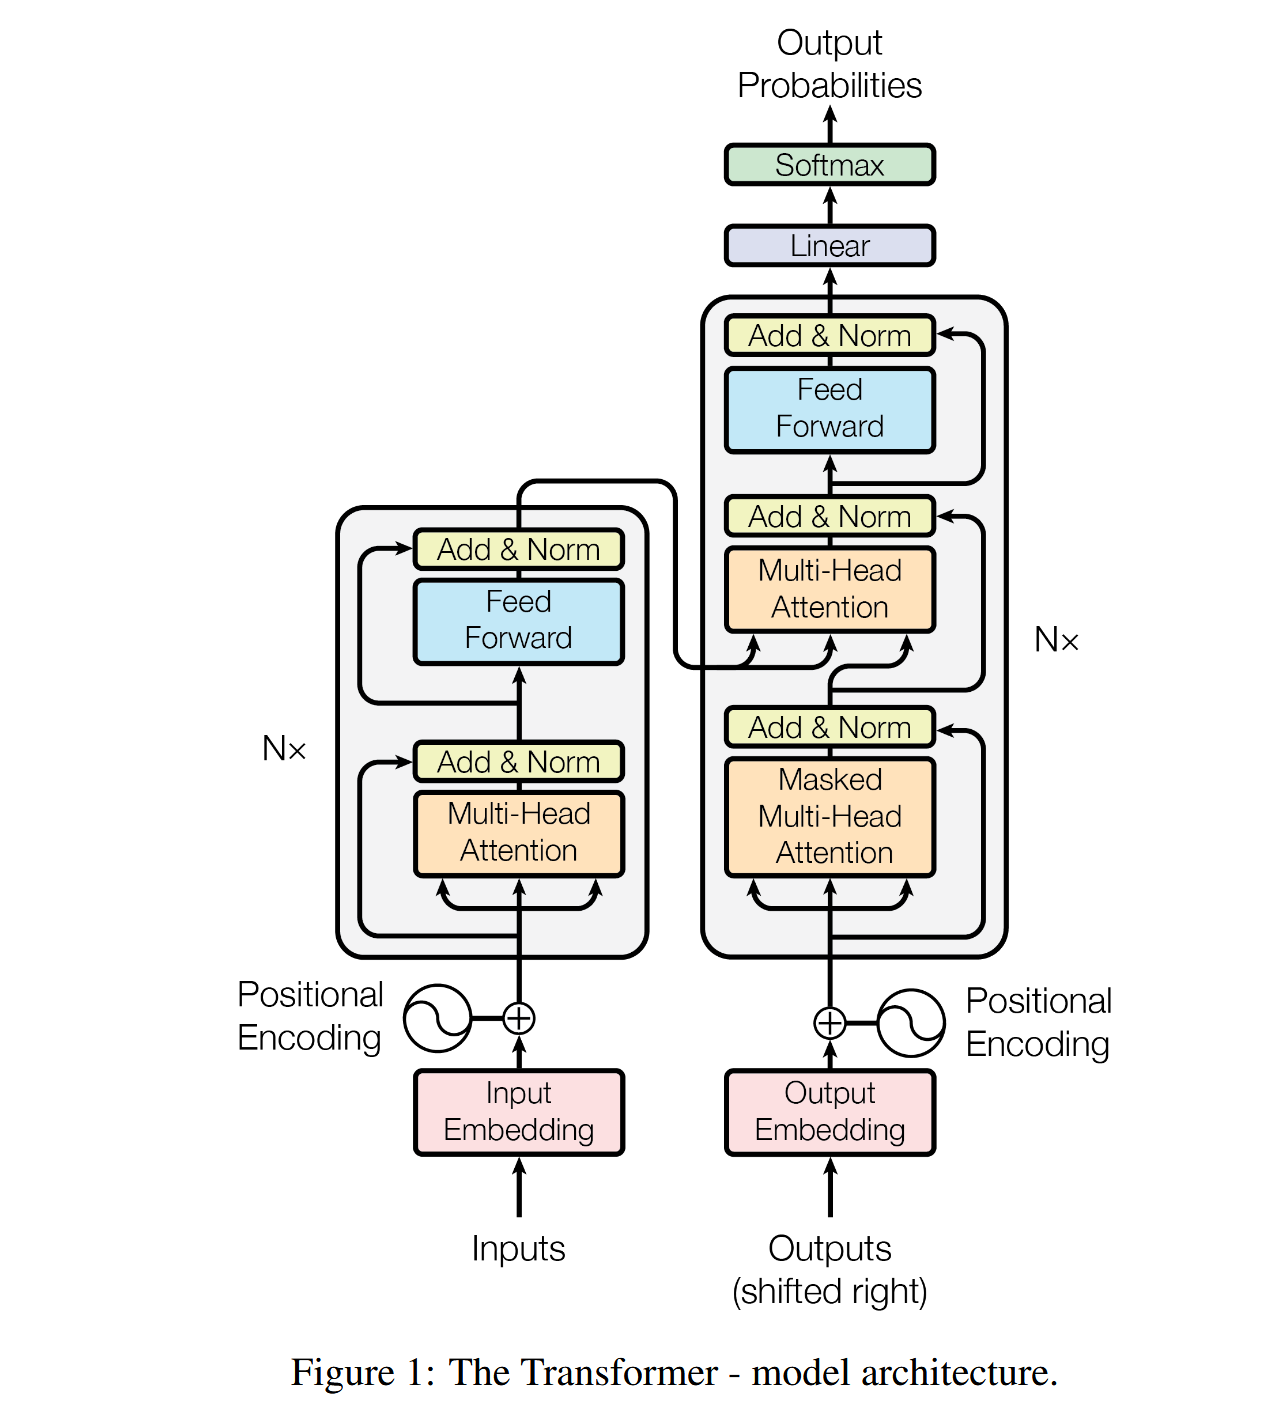

In [41]:
Image(filename='images/model_architecture.png')

In [42]:
# Model Architecture
# 使用EncoderDecoder类来实现编码器-解码器结构
class EncoderDecoder(nn.Module):
    """
    A standard Encoder-Decoder architecture. 
    Base for this and many other models.
    """
    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        #初始化函数中有5个参数，分别是编码器对象，解码器对象,源数据嵌入函数，目标数据嵌入函数，以及输出部分的类别生成器对象.
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed    # input embedding module(input embedding + positional encode)
        self.tgt_embed = tgt_embed    # ouput embedding module
        self.generator = generator    # output generation module
        
    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        #在forward函数中，有四个参数，source代表源数据，target代表目标数据,source_mask和target_mask代表对应的掩码张量,在函数中，将source source_mask传入编码函数，得到结果后与source_mask target 和target_mask一同传给解码函数
        memory = self.encode(src, src_mask)
        res = self.decode(memory, src_mask, tgt, tgt_mask)
        return res
    
    def encode(self, src, src_mask):
        #编码函数，以source和source_mask为参数,使用src_embed对source做处理，然后和source_mask一起传给self.encoder
        src_embedds = self.src_embed(src)
        return self.encoder(src_embedds, src_mask)
    
    def decode(self, memory, src_mask, tgt, tgt_mask):
        #解码函数，以memory即编码器的输出，source_mask target target_mask为参数,使用tgt_embed对target做处理，然后和source_mask,target_mask,memory一起传给self.decoder
        target_embedds = self.tgt_embed(tgt)
        return self.decoder(target_embedds, memory, src_mask, tgt_mask)

In [43]:
# Full Model
def make_model(src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1):
    """
    构建模型
    params:
        src_vocab:
        tgt_vocab:
        N: 编码器和解码器堆叠基础模块的个数
        d_model: 模型中embedding的size，默认512
        d_ff: FeedForward Layer层中embedding的size，默认2048
        h: MultiHeadAttention中多头的个数，必须被d_model整除
        dropout:
    """
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab))
    
    # This was important from their code. 
    # Initialize parameters with Glorot / fan_avg.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

## 5, 总结问答
这一部分，对Transformer中的每个部分的作用做了一个总结，仅供参考。

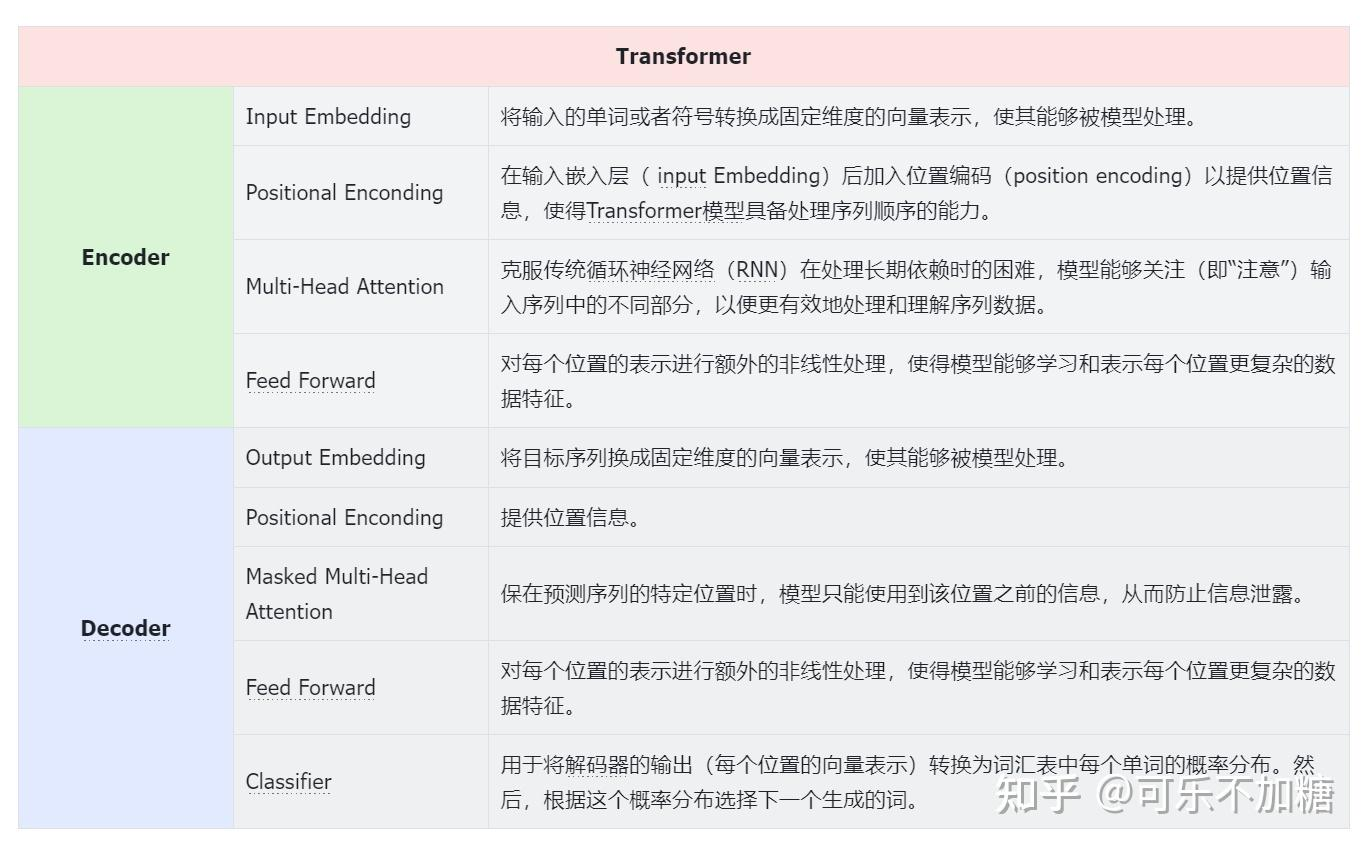

In [44]:
Image(filename='images/summary.jpg')

## 6, 代码实现

## 7, 相关问题

In [45]:
import os
from os.path import exists
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.functional import log_softmax, pad
import math, copy, time
from torch.autograd import Variable
import matplotlib.pyplot as plt
import seaborn 
import warnings
import altair as alt
import pandas as pd
# import torchtext.datasets as datasets
# from torchtext.data.functional import to_map_style_dataset
from torch.utils.data import DataLoader
# from torchtext.vocab import build_vocab_from_iterator
# import spacy
import GPUtil
from torch.utils.data.distributed import DistributedSampler
import torch.distributed as dist
import torch.multiprocessing as mp
from torch.nn.parallel import DistributedDataParallel as DDP
seaborn.set_context(context="talk")
%matplotlib inline


# Transformer Block
class EncoderDecoder(nn.Module):
    """
    A standard Encoder-Decoder architecture. Base for this and many
    other models.
    """

    def __init__(self, encoder, decoder, src_embed, tgt_embed, generator):
        super(EncoderDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.src_embed = src_embed
        self.tgt_embed = tgt_embed
        self.generator = generator

    def forward(self, src, tgt, src_mask, tgt_mask):
        "Take in and process masked src and target sequences."
        return self.decode(self.encode(src, src_mask), src_mask, tgt, tgt_mask)

    def encode(self, src, src_mask):
        return self.encoder(self.src_embed(src), src_mask)

    def decode(self, memory, src_mask, tgt, tgt_mask):
        return self.decoder(self.tgt_embed(tgt), memory, src_mask, tgt_mask)



class Generator(nn.Module):
    "Define standard linear + softmax generation step."

    def __init__(self, d_model, vocab):
        super(Generator, self).__init__()
        self.proj = nn.Linear(d_model, vocab)

    def forward(self, x):
        return log_softmax(self.proj(x), dim=-1)


# 编码Block
class Encoder(nn.Module):
    "Core encoder is a stack of N layers"

    def __init__(self, layer, N):
        super(Encoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, mask):
        "Pass the input (and mask) through each layer in turn."
        for layer in self.layers:
            x = layer(x, mask)
        return self.norm(x)


class LayerNorm(nn.Module):
    "Construct a layernorm module (See citation for details)."

    def __init__(self, features, eps=1e-6):
        super(LayerNorm, self).__init__()
        self.a_2 = nn.Parameter(torch.ones(features))
        self.b_2 = nn.Parameter(torch.zeros(features))
        self.eps = eps

    def forward(self, x):
        mean = x.mean(-1, keepdim=True)
        std = x.std(-1, keepdim=True)
        return self.a_2 * (x - mean) / (std + self.eps) + self.b_2

class SublayerConnection(nn.Module):
    """
    A residual connection followed by a layer norm.
    Note for code simplicity the norm is first as opposed to last.
    """

    def __init__(self, size, dropout):
        super(SublayerConnection, self).__init__()
        self.norm = LayerNorm(size)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, sublayer):
        "Apply residual connection to any sublayer with the same size."
        return x + self.dropout(sublayer(self.norm(x)))


class EncoderLayer(nn.Module):
    "Encoder is made up of self-attn and feed forward (defined below)"

    def __init__(self, size, self_attn, feed_forward, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = self_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 2)
        self.size = size

    def forward(self, x, mask):
        "Follow Figure 1 (left) for connections."
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, mask))
        return self.sublayer[1](x, self.feed_forward)


## 解码 Block
class Decoder(nn.Module):
    "Generic N layer decoder with masking."

    def __init__(self, layer, N):
        super(Decoder, self).__init__()
        self.layers = clones(layer, N)
        self.norm = LayerNorm(layer.size)

    def forward(self, x, memory, src_mask, tgt_mask):
        for layer in self.layers:
            x = layer(x, memory, src_mask, tgt_mask)
        return self.norm(x)

# 解码一个层（掩码自注意力，编码输出，前馈网络，残差网络+层归一化）
class DecoderLayer(nn.Module):
    "Decoder is made of self-attn, src-attn, and feed forward (defined below)"

    def __init__(self, size, self_attn, src_attn, feed_forward, dropout):
        super(DecoderLayer, self).__init__()
        self.size = size
        self.self_attn = self_attn
        self.src_attn = src_attn
        self.feed_forward = feed_forward
        self.sublayer = clones(SublayerConnection(size, dropout), 3)

    def forward(self, x, memory, src_mask, tgt_mask):
        "Follow Figure 1 (right) for connections."
        m = memory
        x = self.sublayer[0](x, lambda x: self.self_attn(x, x, x, tgt_mask))
        x = self.sublayer[1](x, lambda x: self.src_attn(x, m, m, src_mask))
        return self.sublayer[2](x, self.feed_forward)

# 掩码
def subsequent_mask(size):
    "Mask out subsequent positions."
    attn_shape = (1, size, size)
    subsequent_mask = torch.triu(torch.ones(attn_shape), diagonal=1).type(
        torch.uint8
    )
    return subsequent_mask == 0

# 自注意力
def attention(query, key, value, mask=None, dropout=None):
    "Compute 'Scaled Dot Product Attention'"
    d_k = query.size(-1)
    scores = torch.matmul(query, key.transpose(-2, -1)) / math.sqrt(d_k)
    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)
    p_attn = scores.softmax(dim=-1)
    if dropout is not None:
        p_attn = dropout(p_attn)
    return torch.matmul(p_attn, value), p_attn


class MultiHeadedAttention(nn.Module):
    def __init__(self, h, d_model, dropout=0.1):
        "Take in model size and number of heads."
        super(MultiHeadedAttention, self).__init__()
        assert d_model % h == 0
        # We assume d_v always equals d_k
        self.d_k = d_model // h
        self.h = h
        self.linears = clones(nn.Linear(d_model, d_model), 4)
        self.attn = None
        self.dropout = nn.Dropout(p=dropout)

    def forward(self, query, key, value, mask=None):
        "Implements Figure 2"
        if mask is not None:
            # Same mask applied to all h heads.
            mask = mask.unsqueeze(1)
        nbatches = query.size(0)

        # 1) Do all the linear projections in batch from d_model => h x d_k
        query, key, value = [
            lin(x).view(nbatches, -1, self.h, self.d_k).transpose(1, 2)
            for lin, x in zip(self.linears, (query, key, value))
        ]

        # 2) Apply attention on all the projected vectors in batch.
        x, self.attn = attention(
            query, key, value, mask=mask, dropout=self.dropout
        )

        # 3) "Concat" using a view and apply a final linear.
        x = (
            x.transpose(1, 2)
            .contiguous()
            .view(nbatches, -1, self.h * self.d_k)
        )
        del query
        del key
        del value
        return self.linears[-1](x)

class PositionwiseFeedForward(nn.Module):
    "Implements FFN equation."

    def __init__(self, d_model, d_ff, dropout=0.1):
        super(PositionwiseFeedForward, self).__init__()
        self.w_1 = nn.Linear(d_model, d_ff)
        self.w_2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.w_2(self.dropout(self.w_1(x).relu()))

class Embeddings(nn.Module):
    def __init__(self, d_model, vocab):
        super(Embeddings, self).__init__()
        self.lut = nn.Embedding(vocab, d_model)
        self.d_model = d_model

    def forward(self, x):
        return self.lut(x) * math.sqrt(self.d_model)


class PositionalEncoding(nn.Module):
    "Implement the PE function."

    def __init__(self, d_model, dropout, max_len=5000):
        super(PositionalEncoding, self).__init__()
        self.dropout = nn.Dropout(p=dropout)

        # Compute the positional encodings once in log space.
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1)
        div_term = torch.exp(
            torch.arange(0, d_model, 2) * -(math.log(10000.0) / d_model)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)
        self.register_buffer("pe", pe)

    def forward(self, x):
        x = x + self.pe[:, : x.size(1)].requires_grad_(False)
        return self.dropout(x)

In [46]:
def make_model(
    src_vocab, tgt_vocab, N=6, d_model=512, d_ff=2048, h=8, dropout=0.1
):
    "Helper: Construct a model from hyperparameters."
    c = copy.deepcopy
    attn = MultiHeadedAttention(h, d_model)
    ff = PositionwiseFeedForward(d_model, d_ff, dropout)
    position = PositionalEncoding(d_model, dropout)
    model = EncoderDecoder(
        Encoder(EncoderLayer(d_model, c(attn), c(ff), dropout), N),
        Decoder(DecoderLayer(d_model, c(attn), c(attn), c(ff), dropout), N),
        nn.Sequential(Embeddings(d_model, src_vocab), c(position)),
        nn.Sequential(Embeddings(d_model, tgt_vocab), c(position)),
        Generator(d_model, tgt_vocab),
    )

    # This was important from their code.
    # Initialize parameters with Glorot / fan_avg.
    for p in model.parameters():
        if p.dim() > 1:
            nn.init.xavier_uniform_(p)
    return model

In [48]:
def is_interactive_notebook():
    return __name__ == "__main__"


def show_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        return fn(*args)


def execute_example(fn, args=[]):
    if __name__ == "__main__" and RUN_EXAMPLES:
        fn(*args)


class DummyOptimizer(torch.optim.Optimizer):
    def __init__(self):
        self.param_groups = [{"lr": 0}]
        None

    def step(self):
        None

    def zero_grad(self, set_to_none=False):
        None


class DummyScheduler:
    def step(self):
        None

def example_mask():
    LS_data = pd.concat(
        [
            pd.DataFrame(
                {
                    "Subsequent Mask": subsequent_mask(20)[0][x, y].flatten(),
                    "Window": y,
                    "Masking": x,
                }
            )
            for y in range(20)
            for x in range(20)
        ]
    )

    return (
        alt.Chart(LS_data)
        .mark_rect()
        .properties(height=250, width=250)
        .encode(
            alt.X("Window:O"),
            alt.Y("Masking:O"),
            alt.Color("Subsequent Mask:Q", scale=alt.Scale(scheme="viridis")),
        )
        .interactive()
    )


# show_example(example_mask)

In [ ]:
def example_positional():
    pe = PositionalEncoding(20, 0)
    y = pe.forward(torch.zeros(1, 100, 20))

    data = pd.concat(
        [
            pd.DataFrame(
                {
                    "embedding": y[0, :, dim],
                    "dimension": dim,
                    "position": list(range(100)),
                }
            )
            for dim in [4, 5, 6, 7]
        ]
    )

    return (
        alt.Chart(data)
        .mark_line()
        .properties(width=800)
        .encode(x="position", y="embedding", color="dimension:N")
        .interactive()
    )


show_example(example_positional)

In [ ]:
def inference_test():
    test_model = make_model(11, 11, 2)
    test_model.eval()
    src = torch.LongTensor([[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]])
    src_mask = torch.ones(1, 1, 10)

    memory = test_model.encode(src, src_mask)
    ys = torch.zeros(1, 1).type_as(src)

    for i in range(9):
        out = test_model.decode(
            memory, src_mask, ys, subsequent_mask(ys.size(1)).type_as(src.data)
        )
        prob = test_model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.data[0]
        ys = torch.cat(
            [ys, torch.empty(1, 1).type_as(src.data).fill_(next_word)], dim=1
        )

    print("Example Untrained Model Prediction:", ys)


def run_tests():
    for _ in range(10):
        inference_test()


show_example(run_tests)

1, 可能有人会问：为什么这里的位置编码要这么复杂，用sin和cons函数；为什么不直接使用one-hot编码？

原因有三：
- 第一，One-hot编码的维度与序列的长度直接相关。在处理长序列时，如果序列长度较长（比如100），这将导致维度非常高，从而增加了计算复杂性和模型参数。相比之下，Transformer中的位置编码使用正弦和余弦函数，其维度仅与嵌入维度d_{model}相关，与序列长度无关，因此更加高效。
- 第二，用正弦和余弦函数作为位置编码允许模型更好地泛化到不同长度的序列。One-hot编码难以适应序列长度的变化，因为每个位置都有一个固定的、唯一的表示，这在处理比训练时更长的序列时会遇到问题。而基于正弦和余弦的位置编码通过数学函数生成，可以应对任意长度的序列。
- 第三，正弦和余弦位置编码通过其波形的性质可以让模型捕捉到单词之间的相对位置信息。举个例子，假设我们有一个很简短的句子："Hello World"，我们将其输入到Transformer模型中。为简化起见，我们假设模型的嵌入维度是2，这意味着每个单词的位置编码将是一个2维向量。假设位置0的位置编码是 [0, 1]，位置1的位置编码是 [0.0001, 1]；，模型可能会发现当两个词的位置编码在某一维度上的差异是特定模式时（如在我们的例子中，第一个维度的微小变化），这两个词在句子中可能具有特定的相对关系。这种机制使得Transformer能够处理序列数据，理解词语之间的关系，即使它的自注意力机制本身不直接处理序列顺序。


2, 什么是自回归？

在Transformer模型中，自回归任务指的是一种序列生成任务，其中模型在生成每个新元素时都依赖于之前已生成的序列。
简言之，就是模型在预测下一个输出时，会使用到目前为止已经生成的所有输出作为上下文信息。这也是为什么ChatGPT的回答是一个字一个字往外蹦的原因。

3, 在详细介绍之前，我们需要先厘清Decoder部分的输入数据由哪些？看到图中Decoder部分的输入有个Outputs，难免会有些疑惑。

在Transformer模型中，解码器（Decoder）部分的输入通常包括两个主要部分：
- 1. 编码器的输出：图中可以看到编码器（Encoder）和解码器（Decoder）部分有一个连线，编码器（Encoder）的输出是解码器的一部分输入，这个应该也是最容易理解的来。在编码器-解码器架构中，编码器首先处理源序列（例如英文句子），产生一个包含序列信息的表示，然后传递给解码器。解码器利用这些信息来帮助生成目标序列（例如法文句子）。
- 2. 目标序列的前缀：这部分也就是大家在图中看到Decoder部分最下方的Outputs；这个前缀是目标序列当前已知的部分，解码器的任务是基于这个前缀生成序列的下一部分。例如，在机器翻译任务中，如果源语言句子是英文，目标语言句子是法文，那么解码器的输入就是目前已经生成的法文句子部分。当然，在Transformer模型的解码器刚开始工作时，并没有现成的序列前缀，通常会使用一个特殊的起始符号（例如"<sos>"，代表“start of sequence”，也有的用的是"<bos>"）作为序列的初始输入。这个起始符号的作用是表示序列的开始，为模型提供一个明确的起点。
例如，假设目标序列是“Hello World”，那么解码器的输入序列将是“<sos> Hello World”，其中“<sos>”是起始符号